# Main (Primary) Visualization
Specifying this first visualization as being the main deliverable as there was another apporoach I attempted at the bottom of this notebook that I decided not to go with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import PIL
import requests
import seaborn as sns

In [ ]:
# Preprocessing
df = pd.read_csv("Data_Toronto_2025_Outbreaks.csv") # import the dataset
df['Date Outbreak Began'] = pd.to_datetime(df['Date Outbreak Began'], errors='coerce') # convert to datetime fromat
df = df.dropna(subset=['Date Outbreak Began'])  # drop rows with invalid dates

In [10]:
# Extract month for grouping and labeling
df['Month'] = df['Date Outbreak Began'].dt.to_period('M') # extract month from date
df['Month Name'] = df['Date Outbreak Began'].dt.strftime('%B') # write month name in new column

In [11]:
# Reorder months properly
month_order = df[['Month', 'Month Name']].drop_duplicates().sort_values('Month').reset_index(drop=True) # get unique months in order
month_labels = month_order['Month Name'].values # for x-axis labels
month_keys = month_order['Month'].astype(str).values  # for indexing counts

In [5]:
# Set plot style
sns.set_theme(style="whitegrid")

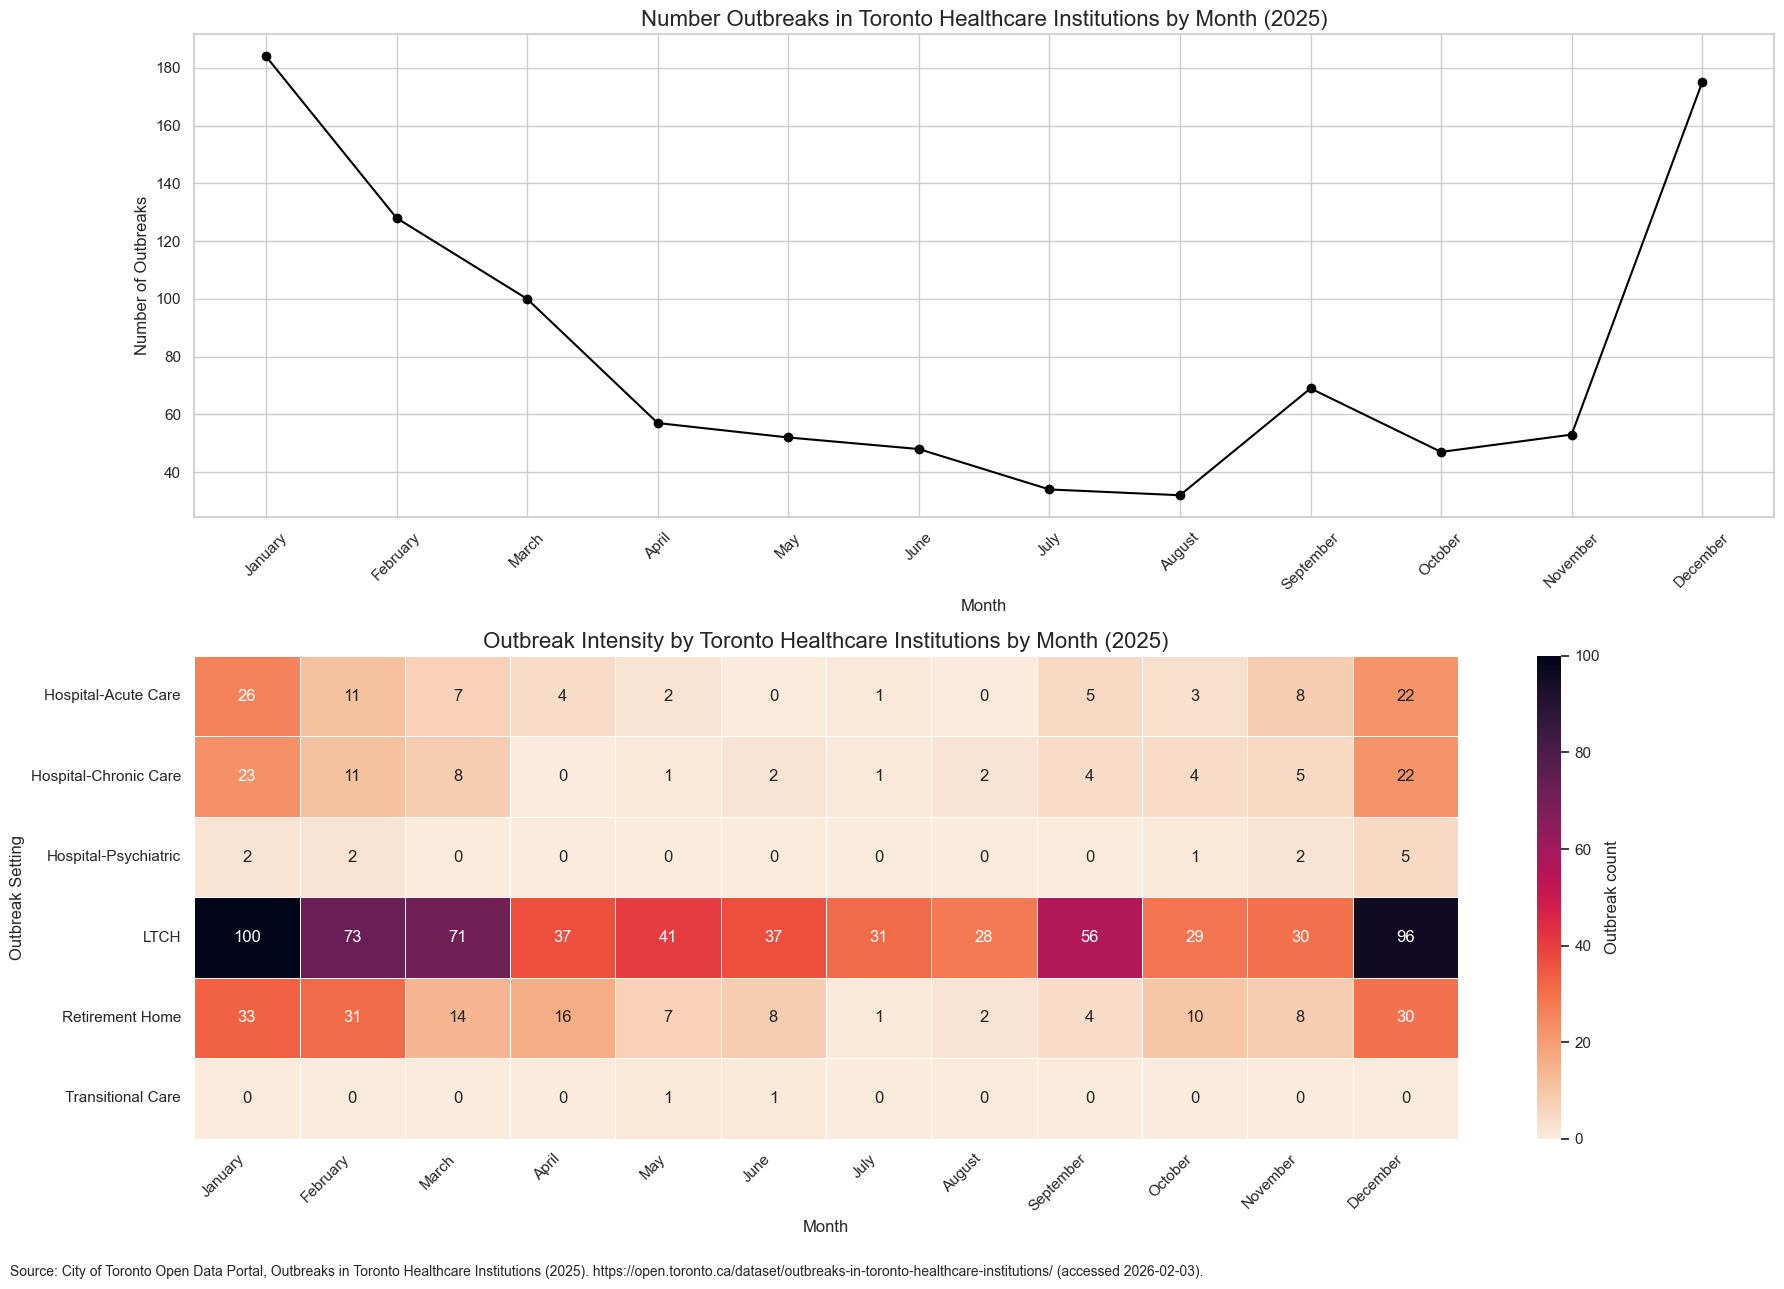

In [34]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(18, 13), sharex=False) # two plots stacked on top of each other

# 1. Line Plot of Monthly Outbreak Counts
monthly_counts = df['Month'].astype(str).value_counts().reindex(month_keys, fill_value=0) # counts number of outbreaks for each month

axes[0].plot(month_labels, monthly_counts.values, marker='o', linestyle='-',color='black') # creates line plot
axes[0].set_title('Number Outbreaks in Toronto Healthcare Institutions by Month (2025)', fontsize=16)   # title
axes[0].set_xlabel('Month') # x-axis title
axes[0].set_ylabel('Number of Outbreaks') # y-axis title
axes[0].tick_params(axis='x', rotation=45) # rotating x-axis labels for better readability

# 2. Heatmap of Outbreaks by Setting and Month
setting_month_counts = df.groupby(['Outbreak Setting', df['Month'].astype(str)]).size().unstack(fill_value=0) # pivot table of counts by setting and month
setting_month_counts = setting_month_counts.reindex(columns=month_keys, fill_value=0) # reindex columns to ensure all months are present

sns.heatmap(setting_month_counts, cmap="rocket_r", linewidths=0.5, annot=True, fmt="d", ax=axes[1],cbar_kws={'label': 'Outbreak count'}) # heatmap with annotations
axes[1].set_title('Outbreak Intensity by Toronto Healthcare Institutions by Month (2025)', fontsize=16) # title
axes[1].set_xlabel('Month') # x-axis title
axes[1].set_ylabel('Outbreak Setting') # y-axis title
axes[1].set_xticks(np.arange(len(month_labels)) + 0.5) # set x-ticks to be in the center of each cell
axes[1].set_xticklabels(month_labels, rotation=45, ha='right') # set x-tick labels



caption = ("Source: City of Toronto Open Data Portal, Outbreaks in Toronto Healthcare Institutions (2025). "
           "https://open.toronto.ca/dataset/outbreaks-in-toronto-healthcare-institutions/ "
           "(accessed 2026-02-03).")

fig.text(
    0.01, 0.01, caption,   # x, y in figure coordinates
    ha="left", va="bottom",
    fontsize=10,
    wrap=True
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

# The Other Approach
I'm not a fan of this one but I'm leaving it here for reference when I discuss the other approach I tried taking to combine information on the number of outbreaks across months and the variation in those numbers across the settings.

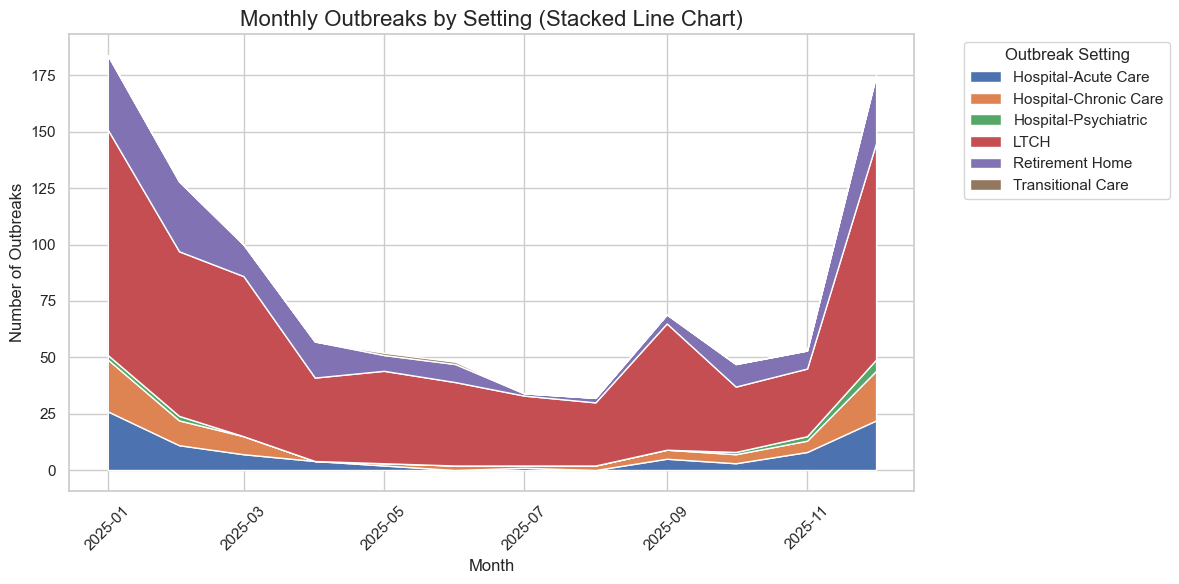

In [15]:
# Recreate the monthly_setting_counts variable
df['Date Outbreak Began'] = pd.to_datetime(df['Date Outbreak Began'], errors='coerce')
df['Month'] = df['Date Outbreak Began'].dt.to_period('M')

# Group and count outbreaks by Month and Outbreak Setting
monthly_setting_counts = df.groupby(['Month', 'Outbreak Setting']).size().unstack(fill_value=0)

# Convert index to datetime for plotting
monthly_setting_counts.index = monthly_setting_counts.index.to_timestamp()

# Plot stacked line (area) chart
plt.figure(figsize=(12, 6))

bottom = np.zeros(len(monthly_setting_counts))
for column in monthly_setting_counts.columns:
    plt.fill_between(monthly_setting_counts.index,
                     bottom,
                     bottom + monthly_setting_counts[column].values,
                     label=column)
    bottom += monthly_setting_counts[column].values

plt.title('Monthly Outbreaks by Setting (Stacked Line Chart)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Outbreaks')
plt.xticks(rotation=45)
plt.legend(title='Outbreak Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
